# Cell Type Annotation Validation for GSE240016

GSE240016 is already annotated. This notebook skips CellTypist and treats the existing `cell_type` and `cell_type_subset` columns as the working ground truth, then validates major thymic stromal compartments with marker dotplots.

## 1. Setup

We load the preprocessed object from notebook 03, preserve existing annotation, and save validation figures to `figures/`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

np.random.seed(0)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white")

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DIR / "thymus_preprocessed.h5ad"
if not input_path.exists():
    raise FileNotFoundError(f"Missing {input_path}. Run notebook 03 first.")

adata = sc.read_h5ad(input_path)
print(adata)

AnnData object with n_obs × n_vars = 22877 × 25211
    obs: 'sample', 'stage', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.4', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'leiden_0.1', 'leiden_0.3', 'leiden_0.5', 'leiden_0.7', 'leiden_0.9', 'cell_type', 'cell_type_subset', 'age_group'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'day_colors', 'hvg', 'leiden'

## 2. Existing Annotation Summary

The published `cell_type` labels capture broad compartments, while `cell_type_subset` gives finer stromal and TEC states. We use these directly rather than replacing them with automated immune-cell annotation.

In [2]:
required = ["cell_type", "cell_type_subset", "stage"]
missing = [col for col in required if col not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing required annotation columns: {missing}")

adata.obs["age_group"] = adata.obs["stage"].astype("category")

print("cell_type counts:")
print(adata.obs["cell_type"].value_counts(dropna=False))
print("\ncell_type_subset counts:")
print(adata.obs["cell_type_subset"].value_counts(dropna=False))
print("\nobsm keys:", list(adata.obsm.keys()))

cell_type counts:
cell_type
FB           13238
TEC           6162
EC            1660
7:vSMC/PC      965
6:MEC          772
8:nmSC          80
Name: count, dtype: int64

cell_type_subset counts:
cell_type_subset
5:medFB                  4722
4:intFB                  4571
3:capsFB                 3866
13:mTEC1                 1635
15:mTEC2                 1383
1:capEC                  1085
7:vSMC/PC                 965
6:MEC                     772
10:aaTEC1                 733
17:mimetic(tuft)          405
12:early Pr               396
14:mTEC-prol              383
12:cTEC                   374
0:arEC                    325
11:aaTEC2                 275
2:venEC                   250
18:mimetic(neuroendo)     210
16:mimetic(basal)         162
19:mimetic(goblet)        159
8:nmSC                     80
9:Fat                      79
20:mimetic(microfold)      47
Name: count, dtype: int64

obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']


## 3. Manual Marker Validation

Marker validation checks whether the existing annotations match known thymic stromal biology. cTEC and mTEC separation is especially important for LOX analysis because subtype-specific matrix remodeling or EMT-like states can be hidden if all TECs are pooled together.

Available markers:
cTEC: ['Psmb11', 'Prss16', 'Ly75', 'Ctsl']
mTEC: ['Aire', 'Krt5', 'Krt14', 'Trp63']
Fibroblasts: ['Col1a1', 'Col3a1', 'Pdgfra', 'Vim']
Endothelial: ['Pecam1', 'Cdh5', 'Kdr']

Missing markers:


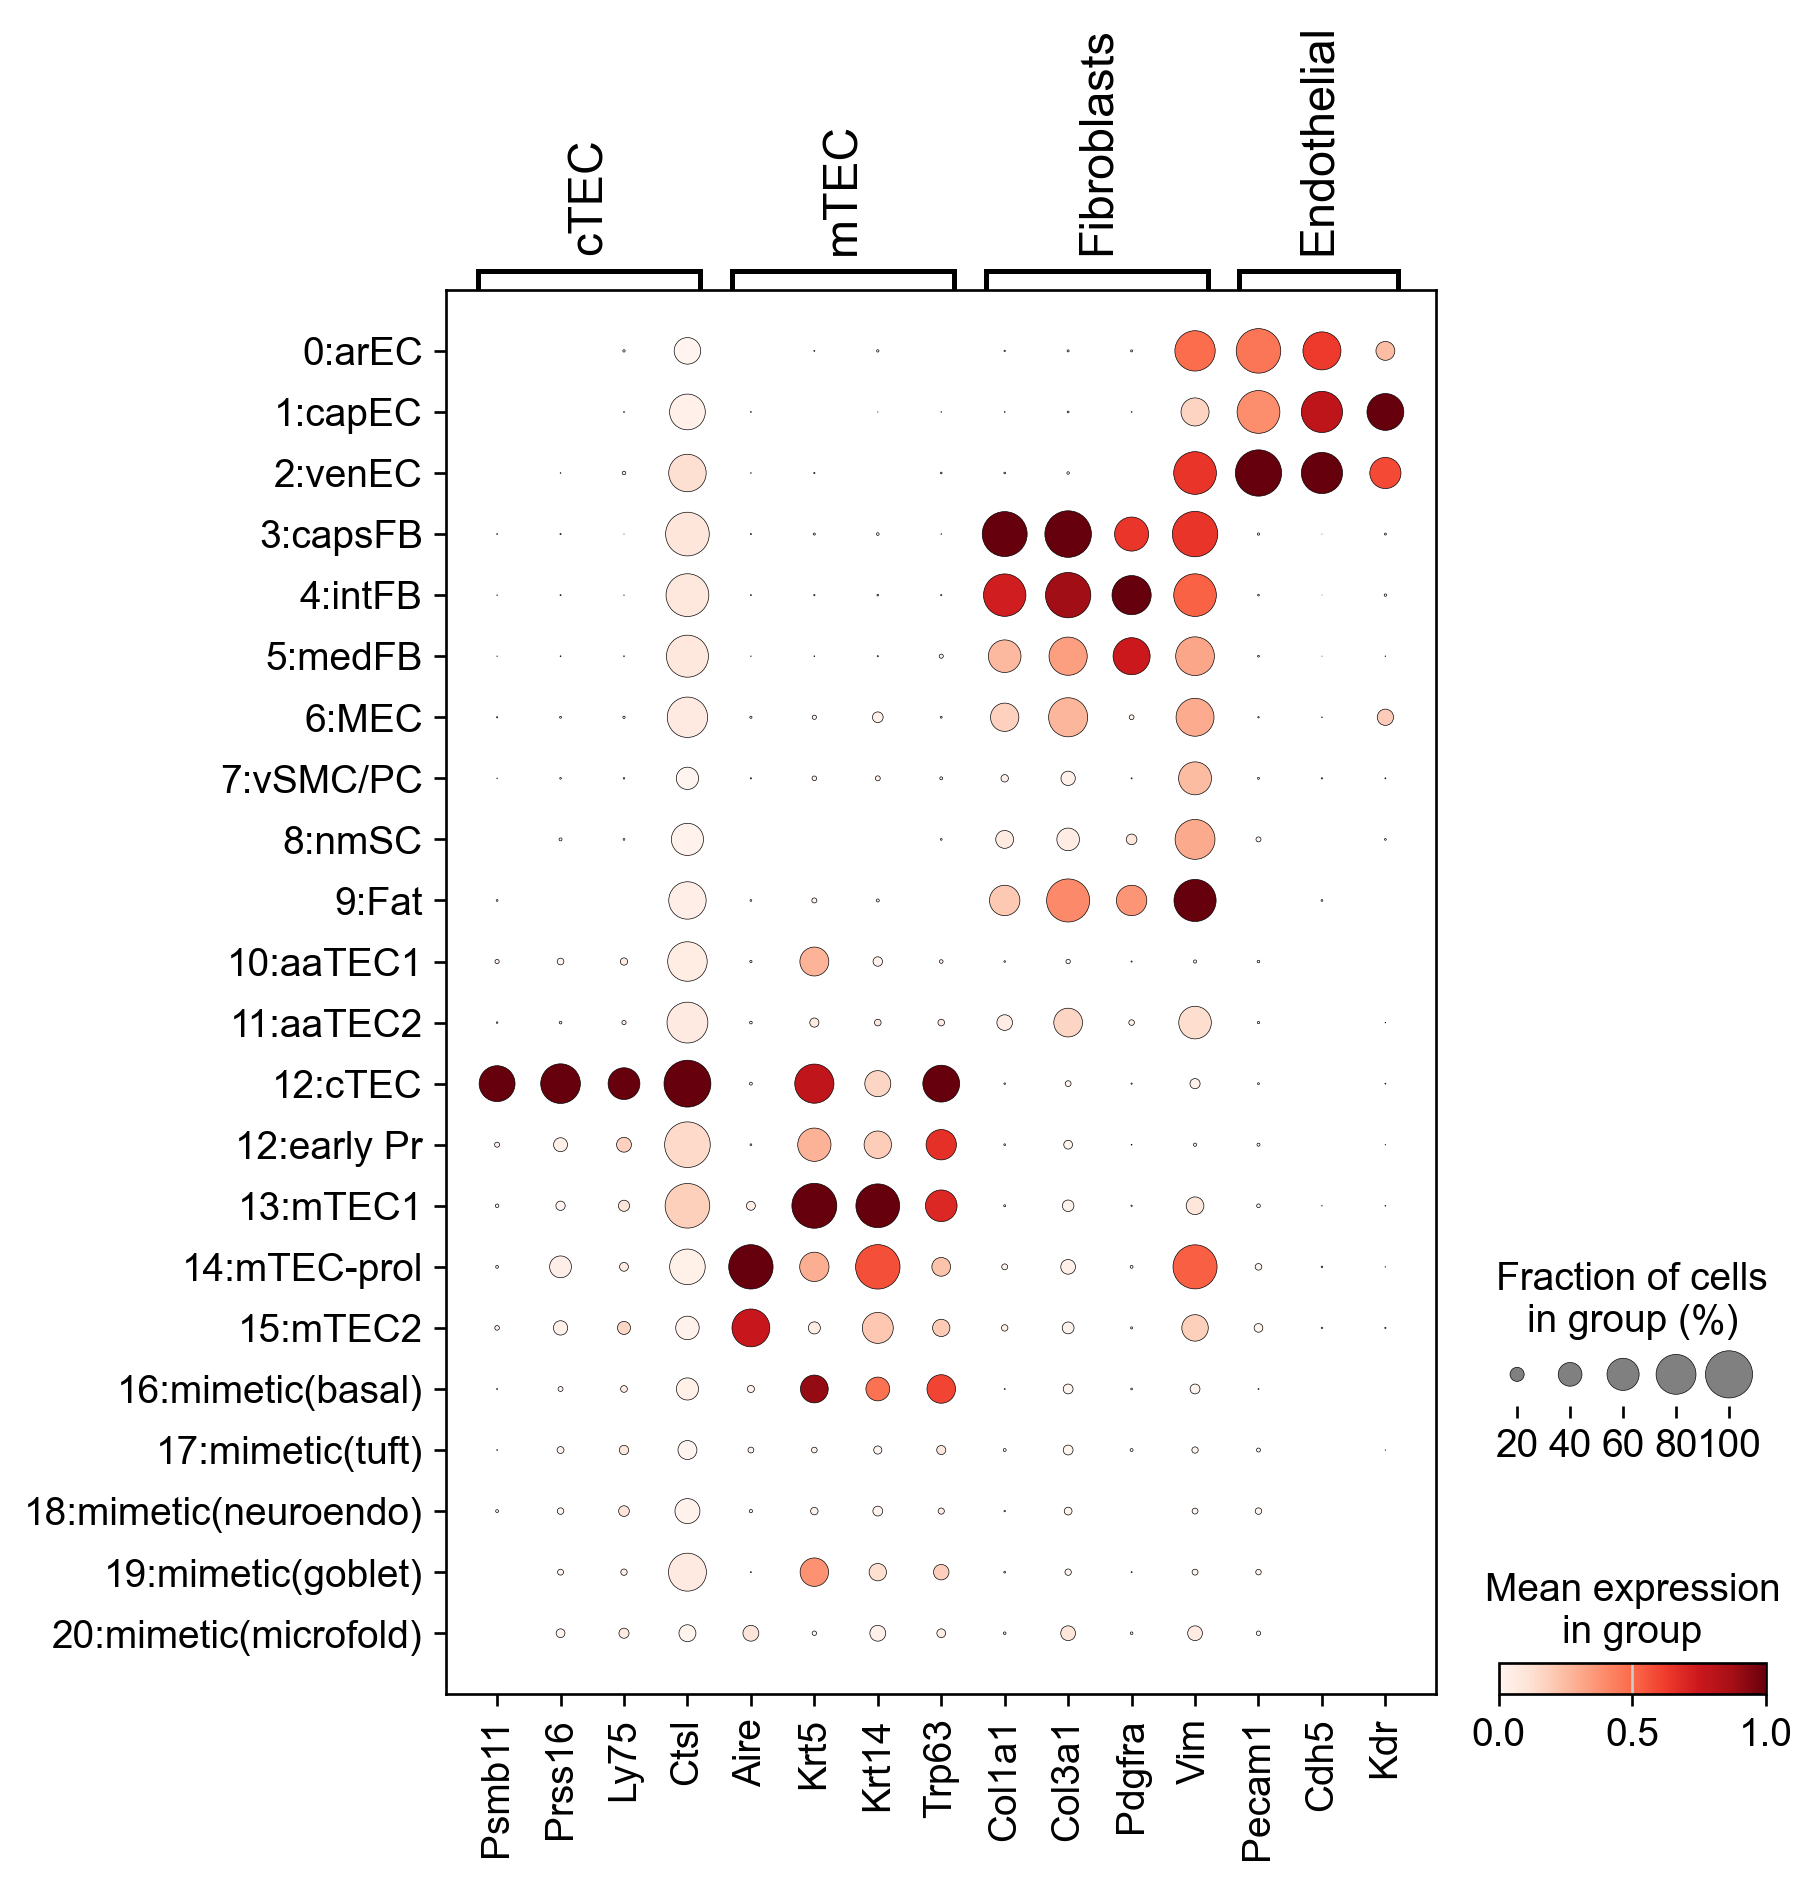

In [3]:
marker_sets = {
    "cTEC": ["Psmb11", "Prss16", "Ly75", "Ctsl"],
    "mTEC": ["Aire", "Krt5", "Krt14", "Trp63"],
    "Fibroblasts": ["Col1a1", "Col3a1", "Pdgfra", "Vim"],
    "Endothelial": ["Pecam1", "Cdh5", "Kdr"],
}

gene_names = adata.var_names.astype(str)
available_marker_sets = {label: [g for g in genes if g in gene_names] for label, genes in marker_sets.items()}
missing_marker_sets = {label: [g for g in genes if g not in gene_names] for label, genes in marker_sets.items()}

print("Available markers:")
for label, genes in available_marker_sets.items():
    print(f"{label}: {genes}")
print("\nMissing markers:")
for label, genes in missing_marker_sets.items():
    if genes:
        print(f"{label}: {genes}")

plot_marker_sets = {label: genes for label, genes in available_marker_sets.items() if genes}
if not plot_marker_sets:
    raise ValueError("No requested marker genes were found.")

sc.pl.dotplot(adata, plot_marker_sets, groupby="cell_type_subset", standard_scale="var", dendrogram=False, show=False)
plt.savefig(FIGURES_DIR / "existing_annotation_marker_dotplot_by_subset.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. UMAP of Published Annotation and Age

The existing UMAP is plotted by broad cell type, fine cell type subset, and `stage` so age-associated structure can be inspected without recomputing embeddings.

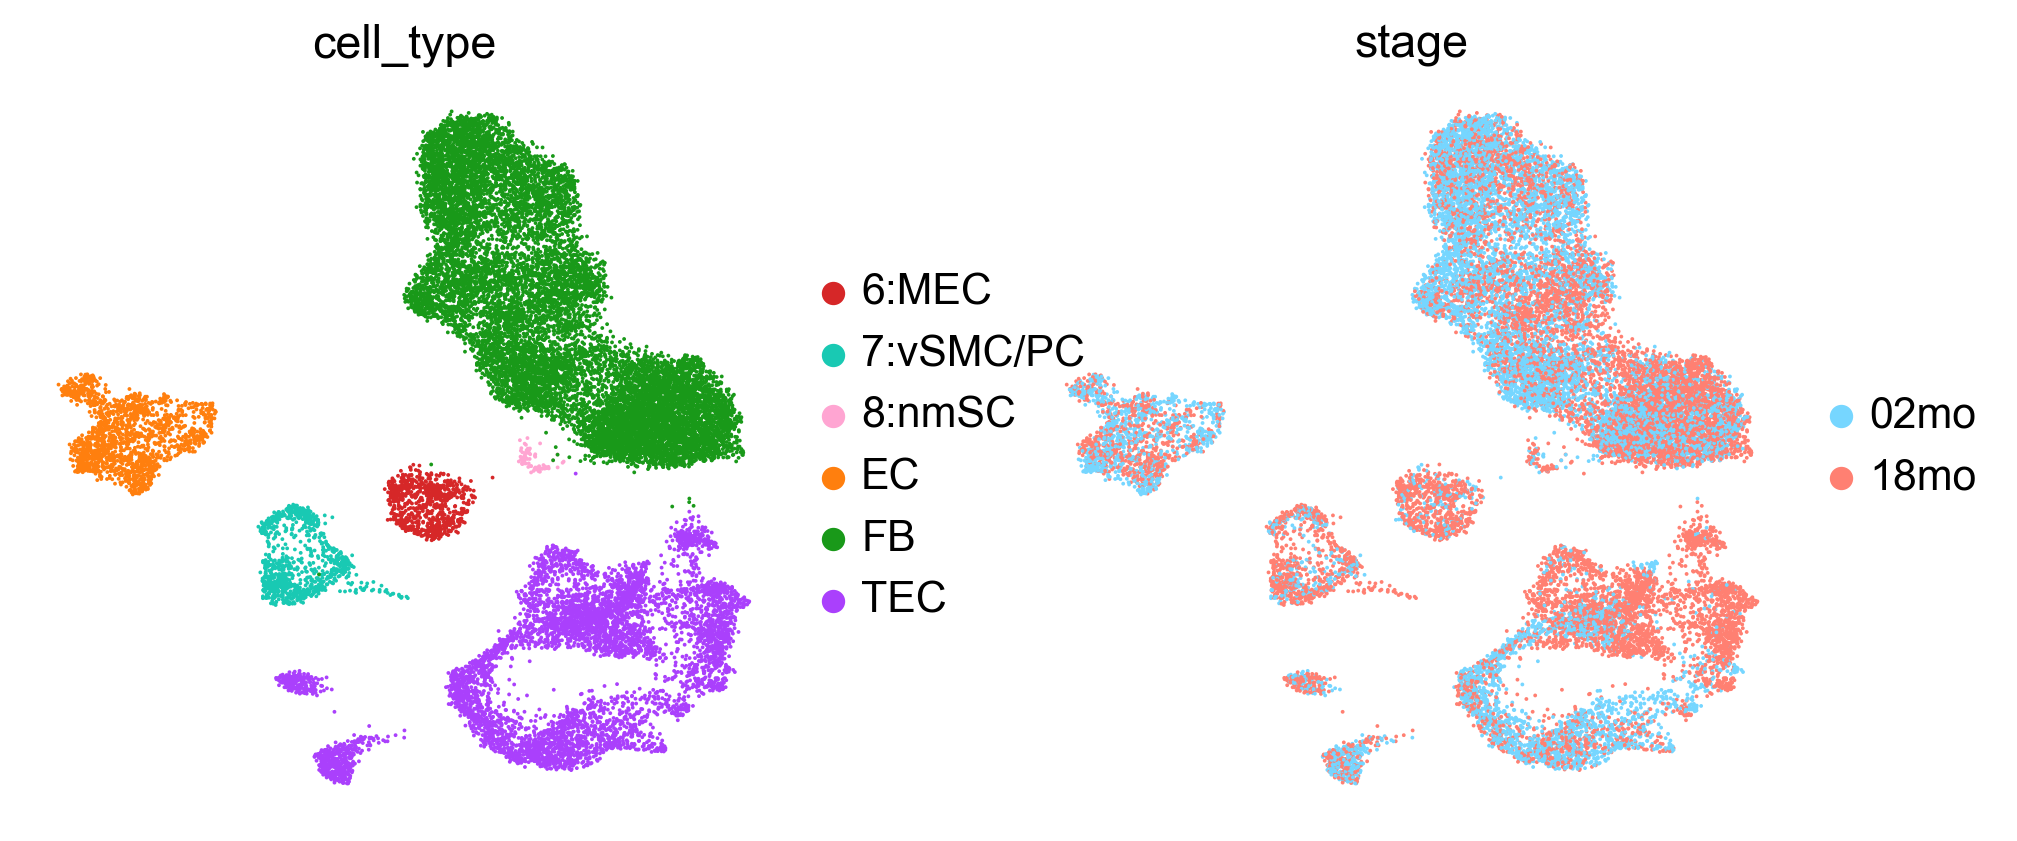

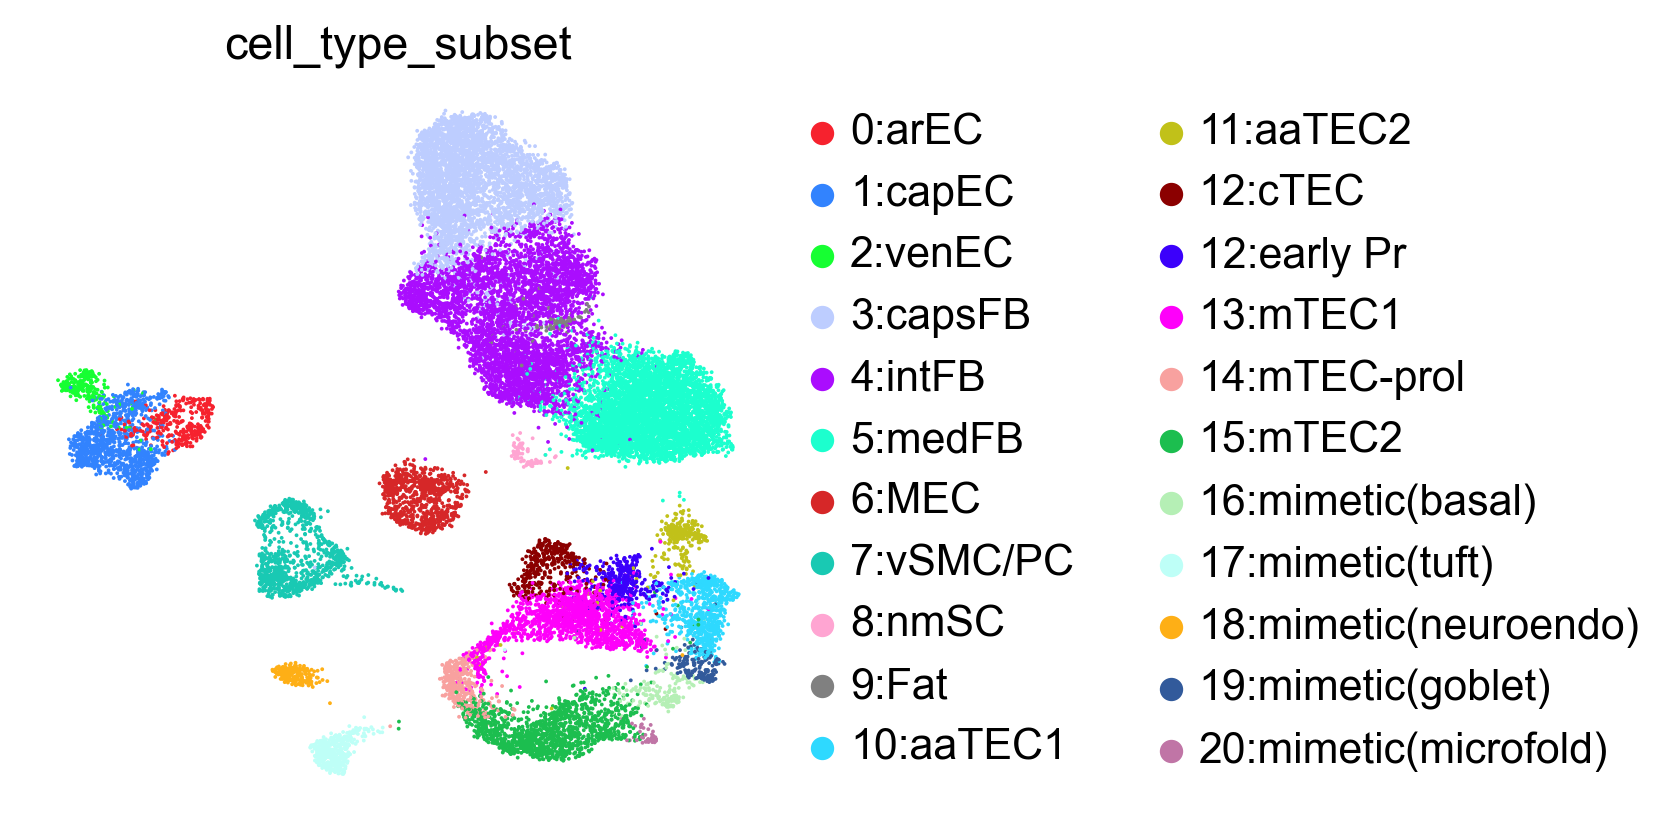

In [4]:
if "X_umap" not in adata.obsm:
    raise KeyError("Expected existing UMAP coordinates in adata.obsm['X_umap'].")

sc.pl.umap(adata, color=["cell_type", "stage"], ncols=2, frameon=False, show=False)
plt.savefig(FIGURES_DIR / "umap_cell_type_stage.png", dpi=300, bbox_inches="tight")
plt.show()

sc.pl.umap(adata, color=["cell_type_subset"], frameon=False, show=False)
plt.savefig(FIGURES_DIR / "umap_cell_type_subset.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Save Annotated Object

The annotated object is saved for LOX expression analysis. No CellTypist labels are added because the dataset already carries curated annotations.

In [5]:
output_path = PROCESSED_DIR / "thymus_annotated.h5ad"
adata.write(output_path)
print(f"Saved annotated object to: {output_path}")

Saved annotated object to: D:\ThymusLOXScan\data\processed\thymus_annotated.h5ad
